____
# Colocalization dataset
- put all variables for reconstruction in the same file


In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir, surface_drifters, depth_drifters, depth_100, depth_50, images_dir, U2, err_acc
from swot import browse_swot_250, add_mask_inside_swot, build_swath_polygon
from diagnosis import dataset_coloc_combs, DRIFTER, ALTI, WD, compute_mean_square, compute_mean_square_groupby

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0

_______
# Data

In [2]:
DRIFTER.keys(), ALTI.keys(), WD.keys()
# wd_depth = '0' or '15'
# ggd_var = 'etaf', 'etac', 'adtf', 'adtc', 'fromduacsv'

(dict_keys(['nofilter', '0.5cpd', '1.5cpd', '2.5cpd', '3cpd']),
 dict_keys(['swot250naive', 'swot250gauss1e3', 'swot250gauss2e3', 'swot250gauss3e3', 'swot250gauss4e3', 'swot250gauss5e3', 'swot2kmnaive', 'swot2kmgauss1e3', 'swot2kmgauss2e3', 'swot2kmgauss3e3', 'swot2kmgauss4e3', 'swot2kmgauss5e3', 'swot2kmgauss1e4']),
 dict_keys(['era5']))

_______
# Compute and project (x = cross, y = alg)

In [3]:
comb_list = [dict(drifter_key='nofilter', alti_key = 'swot2kmnaive', wd_key = 'era5', ggd_var='etaf', wd_depth='0'), 
            dict(drifter_key='nofilter', alti_key = 'swot2kmnaive', wd_key = 'era5', ggd_var='etaf', wd_depth='15')]

DS = dataset_coloc_combs(comb_list, nearest =False)
DS = DS.where(DS.time_to_swot/pd.Timedelta('1h')<12).dropna('row_number')

DSS = DS.where(DS.depth==0, drop=True).isel(id_comb=[0])
DSD = DS.where(DS.depth==15, drop=True).isel(id_comb=[1])

nofilter__swot2kmnaive_etaf__rio_0era5
nofilter__swot2kmnaive_etaf__rio_15era5
Identified SWOT and drifter outliers have been removed


In [5]:
# rotate
def rotate(e, n, phi):
    return np.cos(phi)*e - np.sin(phi)*n, np.sin(phi)*e + np.cos(phi)*n

def crossalg_proj(dsen):
    ds = dsen.copy()
    ds['sumx'] , ds['sumy'] = rotate(dsen.sume, dsen.sumn, dsen.phi)
    dsxy = ds[['sumx','sumy']]
    var = ['acc', 'cor', 'ggd', 'wd', 'sum']
    prod  = [l for l in ds.keys() if 'prodn' in l]
    exc  = [l for l in ds.keys() if 'excn' in l]
    for v in var :
        dsxy[v +'x'] , dsxy[v +'y'] = rotate(dsen[v+'e'], dsen[v+'n'], dsen.phi)

    for direction in ['x', 'y'] : 
            if direction == 'x' : l = {'acc':'accx', 'cor':'corx', 'ggd':'ggdx', 'wd':'wdx'}
            if direction == 'y' : l = {'acc':'accy', 'cor':'cory', 'ggd':'ggdy', 'wd':'wdy'}
                
            # sum 
            dsxy['sum'+direction] = sum([dsxy[l[v]] for v in l])
            
            # simple var + sum- one term
            for v in l :
                dsxy[l[v]] = dsxy[l[v]]
                dsxy['exc'+direction+'_'+v] = dsxy['sum'+direction]-dsxy[l[v]]
                
            #2 by 2 product    
            import itertools  
            couple = list(itertools.combinations(list(l.keys()),2))
            for c in couple : 
                dsxy['prod'+direction+'_'+'_'.join(c)] = dsxy[c[0]+direction] * dsxy[c[1]+direction]
    return dsxy
    
DSr =  crossalg_proj(DS)  

DSSr = DSr.where(DSr.depth==0, drop=True).isel(id_comb=[0])
DSDr = DSr.where(DSr.depth==15, drop=True).isel(id_comb=[1])


__________________
## Surface

150060
7.680285810840972
8.010529169330756
7.765789629433402
7.916613720217638


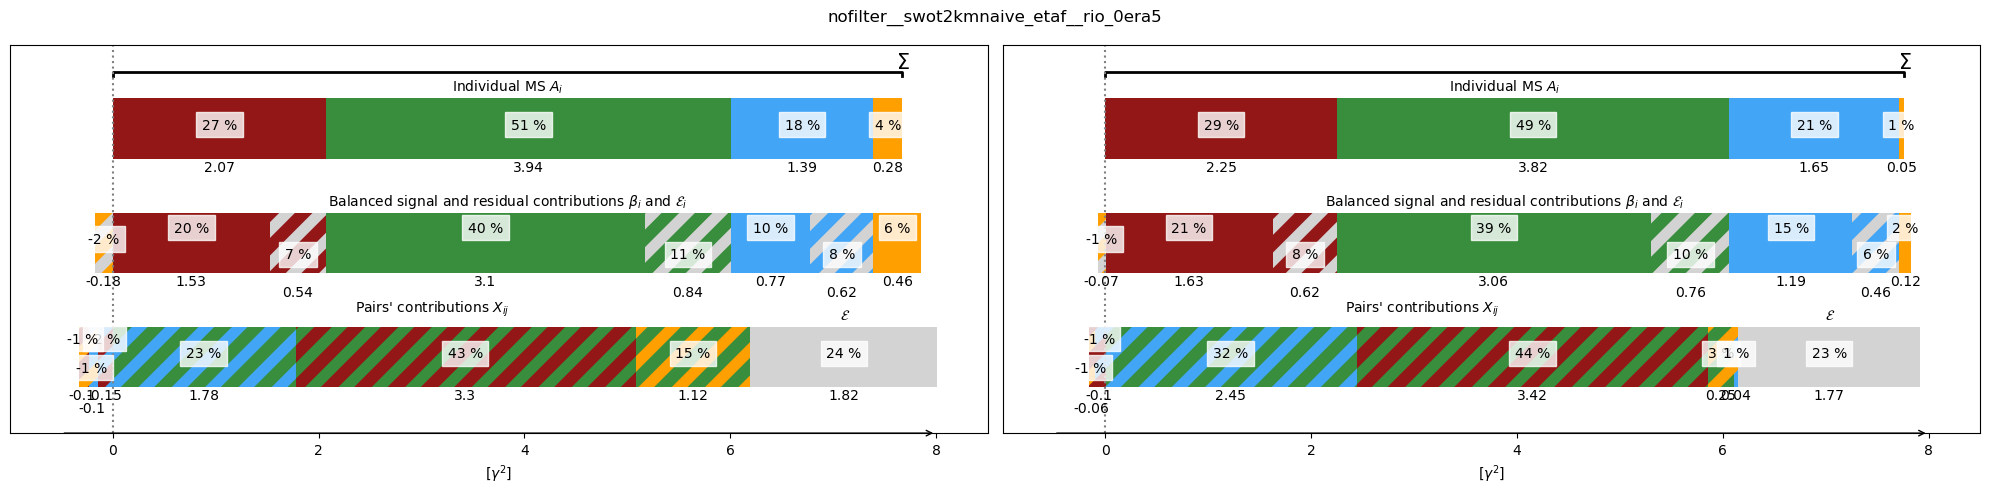

In [6]:
ds = compute_mean_square(DSS, dirname=('e', 'n'))/U2
df = ds.to_dataframe()
print(DSS.sizes['row_number'])
for c in ds.id_comb.values :
    fig, axs = plt.subplots(nrows=1,ncols=2,figsize=(20,5), frameon=False)
    synthetic_figure(df.loc[c], axs[0], dir='e', xlim=[-1, 8])
    synthetic_figure(df.loc[c], axs[1], dir='n', xlim=[-1, 8])
    fig.suptitle(c)
    fig.tight_layout()
    fig.savefig(os.path.join(images_dir, 'closure_figs', c + '_Xy.png'))

150060
7.449419621003591
7.75391924463334
7.996655819270783
8.155517359920553


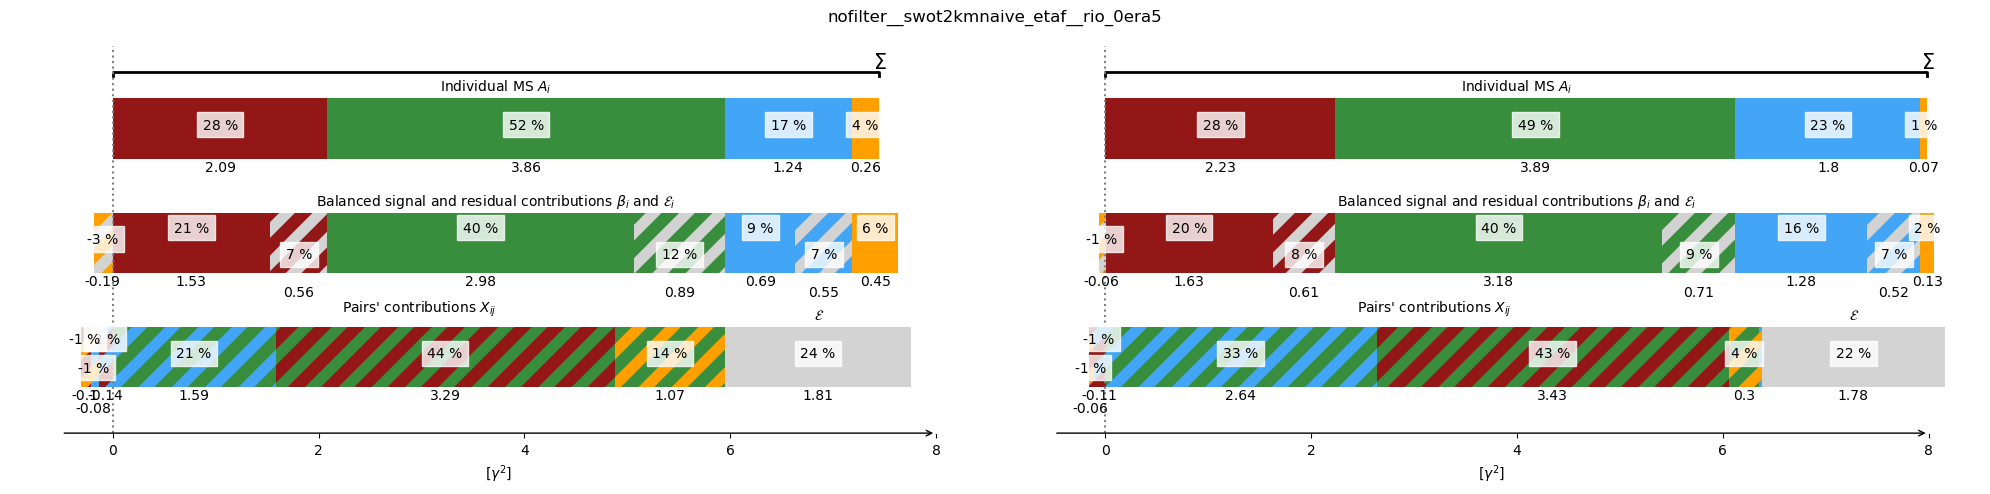

In [7]:
dsr = compute_mean_square(DSSr, dirname=('x', 'y'))/U2
df = dsr.to_dataframe()
print(DSSr.sizes['row_number'])
for c in ds.id_comb.values :
    fig, axs = plt.subplots(nrows=1,ncols=2,figsize=(20,5), frameon=False)
    synthetic_figure(df.loc[c], axs[0], dir='x', xlim=[-1, 8])
    synthetic_figure(df.loc[c], axs[1], dir='y', xlim=[-1, 8])
    fig.suptitle(c)
    fig.tight_layout()
    fig.savefig(os.path.join(images_dir, 'closure_figs', c + '_XY.png'))

_________
# Dependency on the cross_track distance

In [8]:
dfs = pd.read_csv(ALTI['swot2kmnaive']).set_index('row_number')
dfr = DSSr.to_dataframe().reset_index().set_index('row_number')

dfrr = pd.concat([dfs['cross_track_distance'], dfr], axis=1)
ct_dist_bins = np.arange(-70000, 70000, 1000)
dfrr['cross_track_distance_cut'] = pd.cut(dfrr['cross_track_distance'], ct_dist_bins, labels=(ct_dist_bins[1:] + ct_dist_bins[:-1])/2)
dsc = compute_mean_square_groupby(dfrr, groupby = [ 'cross_track_distance_cut'], dir_ = ('x', 'y'))

dsc = dsc.where(dsc.nb_coloc>100)
dsc['cross_track_distance_cut'] = dsc['cross_track_distance_cut']/1000

Text(0.5, 0, 'Cross - track distance [km]')

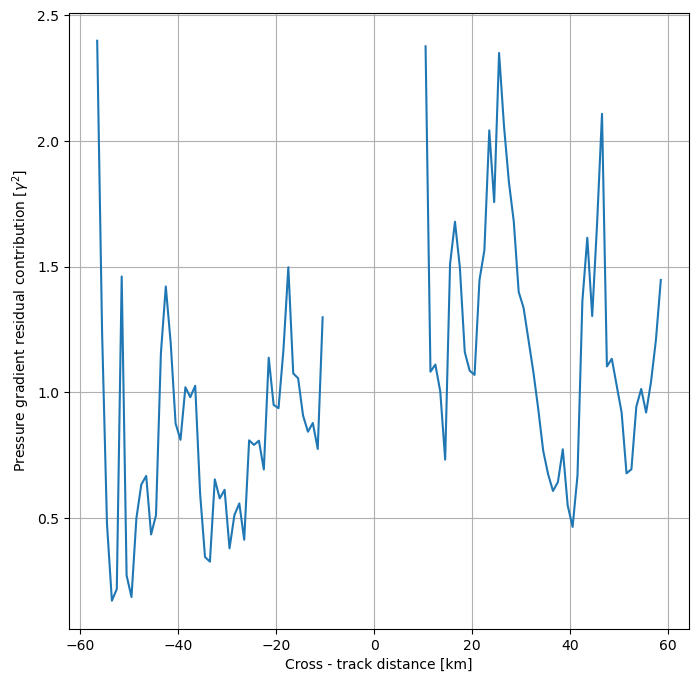

In [9]:
plt.rcParams["axes.edgecolor"] = "k"
fig, ax = plt.subplots(1, 1, figsize=(8,8), frameon=False)
(dsc.Ex_ggd + dsc.Ey_ggd).plot(ax=ax)
ax.grid()
ax.set_ylabel(r'Pressure gradient residual contribution [$\gamma^2$]')
ax.set_xlabel(r'Cross - track distance [km]')

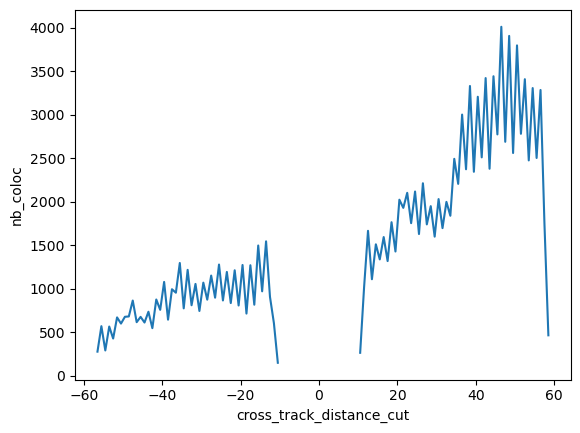

In [10]:
dsc.nb_coloc.plot()

Text(0.5, 0, 'Cross - track distance [km]')

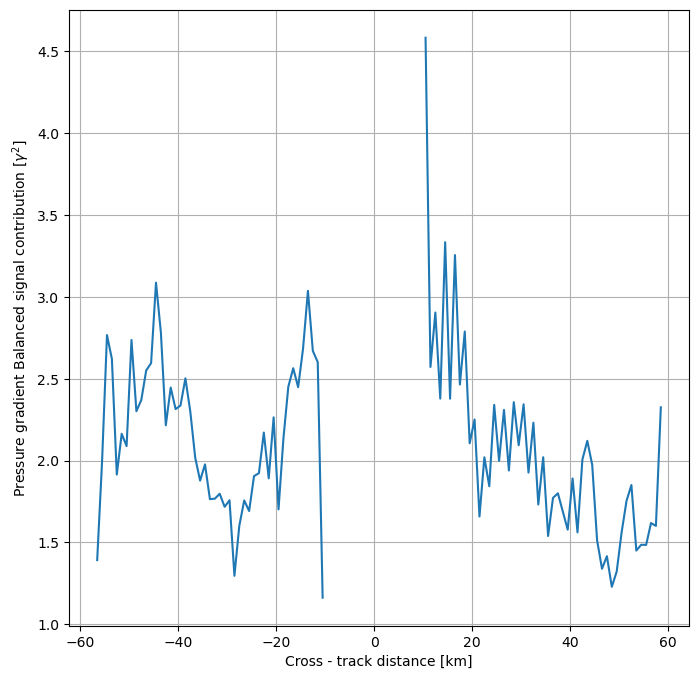

In [11]:
plt.rcParams["axes.edgecolor"] = "k"
fig, ax = plt.subplots(1, 1, figsize=(8,8), frameon=False)
(dsc.Bx_ggd + dsc.By_ggd).plot(ax=ax)
ax.grid()
ax.set_ylabel(r'Pressure gradient Balanced signal contribution [$\gamma^2$]')
ax.set_xlabel(r'Cross - track distance [km]')

_________
# Dependency on the seastate

In [31]:
dfs = pd.read_csv(ALTI['swot2kmnaive']).set_index('row_number')
dfr = DSSr.to_dataframe().reset_index().set_index('row_number')

dfrr = pd.concat([dfs['swh_model'], dfr], axis=1)
swh_dist_bins = np.linspace(0, 4.4, 100)
dfrr['swh_model_cut'] = pd.cut(dfrr['swh_model'], swh_dist_bins, labels=(swh_dist_bins[1:] + swh_dist_bins[:-1])/2)
dsc = compute_mean_square_groupby(dfrr, groupby = [ 'swh_model_cut'], dir_ = ('x', 'y'))

#dsc = dsc.where(dsc.nb_coloc>50)

In [32]:
dfs['swh_model'].max()

4.346731701292661

Text(0.5, 0, 'Sea wave height from model [m]')

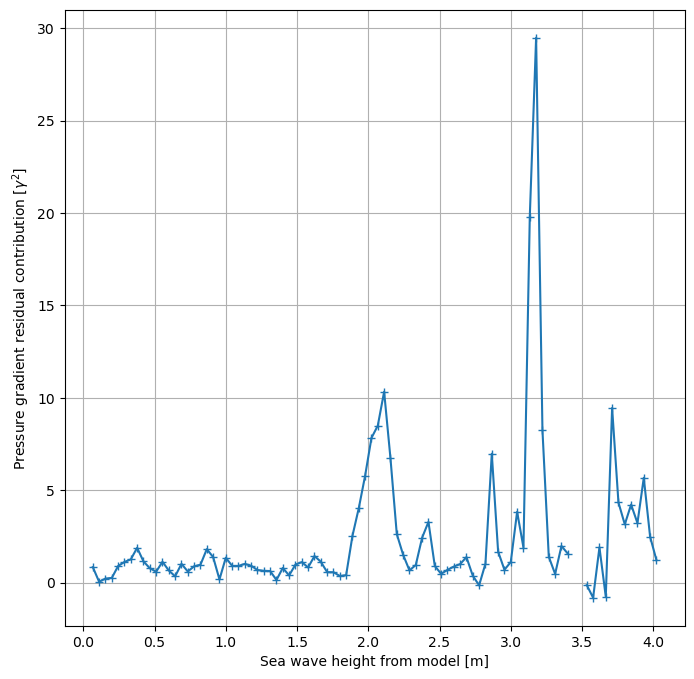

In [33]:
plt.rcParams["axes.edgecolor"] = "k"
fig, ax = plt.subplots(1, 1, figsize=(8,8), frameon=False)
(dsc.Ex_ggd + dsc.Ey_ggd).plot(ax=ax, marker='+')
ax.grid()
ax.set_ylabel(r'Pressure gradient residual contribution [$\gamma^2$]')
ax.set_xlabel(r'Sea wave height from model [m]')

Text(0.5, 0, 'Sea wave height from model [m]')

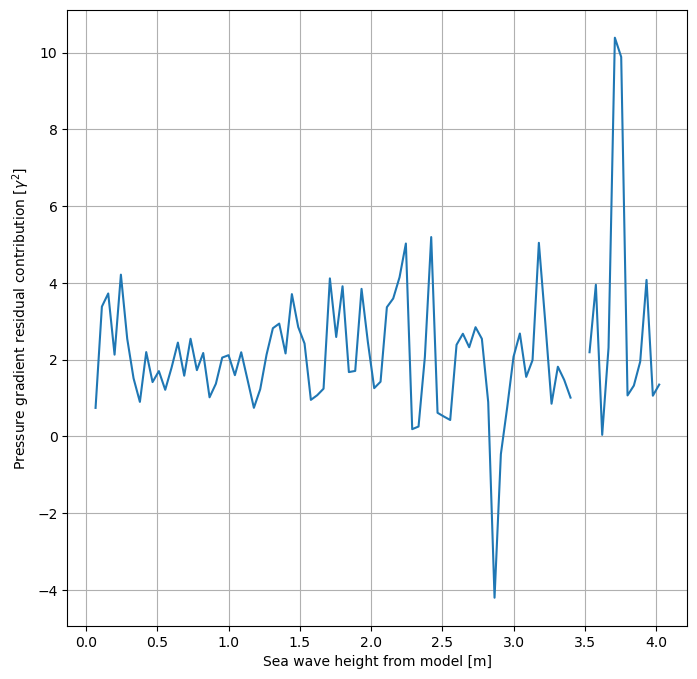

In [35]:
plt.rcParams["axes.edgecolor"] = "k"
fig, ax = plt.subplots(1, 1, figsize=(8,8), frameon=False)
(dsc.Bx_ggd + dsc.By_ggd).plot(ax=ax)
ax.grid()
ax.set_ylabel(r'Pressure gradient Balanced contribution [$\gamma^2$]')
ax.set_xlabel(r'Sea wave height from model [m]')